### Pre-requisites


In [24]:
# import needed python libraries

%matplotlib inline

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import random
import statistics
import functions as fnc


## Dataset

we start by importing the pre-processed dataframes generated in section 1 

In [25]:
df_domC = pd.read_pickle('df_domC.pkl')

Working with a data set with more features was not helpful.

# Section 3

We analyse by domain knowledge what the websites are providing. Hopefuly we could cluster these together. There are 4 labels bellow
These labels will be used for Adjusted rand-index, to numerically evaluate if the cluesters are groupping flows of the same category

| Domain                | Primary Label              | Notes / Supporting Function                                             |
| :-------------------- | :------------------------- | :---------------------------------------------------------------------- |
| adnxs.com             | **Ad Tech / Analytics**    | Advertising exchange (AppNexus); short, frequent tracking/auction flows |
| ads-twitter.com       | **Ad Tech / Analytics**    | Twitter/X advertising delivery and tracking                             |
| chartbeat.com         | **Ad Tech / Analytics**    | Real-time analytics and audience measurement                            |
| contextweb.com        | **Ad Tech / Analytics**    | Contextual advertising and real-time bidding                            |
| disqus.com            | **Social & Community**     | Embedded comment system for websites                                    |
| everesttech.net       | **Ad Tech / Analytics**    | Adobe advertising, tracking, and attribution services                   |
| fastly-insights.com   | **Telemetry & Monitoring** | CDN performance and monitoring telemetry                                |
| fastly.net            | **Infrastructure & CDN**   | Major global content delivery network                                   |
| ftcdn.net             | **Infrastructure & CDN**   | CDN for *Financial Times* media assets                                  |
| giphy.com             | **Media Service**          | GIF search and delivery platform                                        |
| githubusercontent.com | **Infrastructure & CDN**   | Hosting of static assets and raw files                                  |
| krxd.net              | **Ad Tech / Analytics**    | Advertising data management and user tracking                           |
| newrelic.com          | **Telemetry & Monitoring** | Application and infrastructure performance monitoring                   |
| outbrain.com          | **Ad Tech / Analytics**    | Content recommendation and native advertising                           |
| pinterest.com         | **Social & Community**     | Visual discovery and bookmarking platform                               |
| polyfill.io           | **Infrastructure & CDN**   | Delivery of JavaScript polyfills                                        |
| redd.it               | **Social & Community**     | Reddit URL shortener and redirect service                               |
| reddit.com            | **Social & Community**     | Social news aggregation and discussion forum                            |
| scdn.co               | **Media Service**          | SoundCloud CDN for audio streaming                                      |
| slack-edge.com        | **Infrastructure & CDN**   | Slack asset and file delivery via CDN                                   |
| taboola.com           | **Ad Tech / Analytics**    | Content recommendation and advertising                                  |
| twimg.com             | **Infrastructure & CDN**   | Twitter/X image and media CDN                                           |
| twitch.tv             | **Media Service**          | Live video streaming platform                                           |
| twitchcdn.net         | **Media Service**          | Dedicated CDN for Twitch video delivery                                 |
| vimeocdn.com          | **Media Service**          | Video delivery CDN for Vimeo                                            |


In [26]:
df_domC

_s_bytes_all           _s_bytes_retx            \
                               max   average           max   average   
label                                                                  
_other                    1.098770  0.607594      0.203164  0.081594   
adnxs.com                -0.330448 -0.622728     -0.360821 -0.624004   
ads-twitter.com          -0.337825 -0.704748     -0.373731 -0.654992   
chartbeat.com            -0.337809 -0.703769     -0.373586 -0.662096   
contextweb.com           -0.337562 -0.703985     -0.372839 -0.643710   
disqus.com               -0.337441 -0.686542     -0.371380 -0.630463   
everesttech.net          -0.337180 -0.697579     -0.370763 -0.637484   
fastly-insights.com      -0.337735 -0.698992     -0.373460 -0.665569   
fastly.net               -0.327611 -0.522466     -0.361221 -0.460204   
ftcdn.net                -0.326737 -0.301608     -0.347040  0.274010   
giphy.com                -0.127586  0.953545     -0.004313  1.154107   
githubusercontent.com    -0.286081 -0.494127     -0.322313 -0.521119   
krxd.net                 -0.333360 -0.688601     -0.360857 -0.639944   
newrelic.com             -0.336514 -0.683252     -0.372339 -0.632484   
outbrain.com             -0.270860 -0.562319     -0.250290 -0.540027   
pinterest.com            -0.255429 -0.519208     -0.336733 -0.492759   
polyfill.io              -0.334342 -0.692816     -0.372885 -0.642214   
redd.it                  -0.258302  2.315526     -0.239984  2.628409   
reddit.com                0.016717  0.172994     -0.129790  0.084283   
scdn.co                  -0.107237  2.015372      3.375987  3.268464   
slack-edge.com           -0.161609  0.829083     -0.344728  0.000621   
taboola.com               4.748896 -0.032763      3.480418  0.694910   
twimg.com                -0.236434  1.144959     -0.308840  0.206920   
twitch.tv                -0.335610 -0.685637     -0.368710 -0.627466   
twitchcdn.net            -0.335241 -0.590138     -0.348470 -0.241876   
vimeocdn.com              0.524571  2.552207      0.005524  0.923092   

                      _s_pkts_all           _s_pkts_retx            \
                              max   average          max   average   
label                                                                
_other                   1.080869  0.605861     0.199291  0.100818   
adnxs.com               -0.331307 -0.637712    -0.361985 -0.638693   
ads-twitter.com         -0.338281 -0.704291    -0.371915 -0.645785   
chartbeat.com           -0.336058 -0.697934    -0.371915 -0.672943   
contextweb.com          -0.338049 -0.714020    -0.373156 -0.690252   
disqus.com              -0.338131 -0.688809    -0.371667 -0.648431   
everesttech.net         -0.337656 -0.692602    -0.370426 -0.611775   
fastly-insights.com     -0.338065 -0.711345    -0.373901 -0.734912   
fastly.net              -0.327232 -0.525844    -0.362234 -0.483543   
ftcdn.net               -0.327424 -0.332665    -0.348332  0.160619   
giphy.com               -0.129037  0.924221    -0.011963  1.091327   
githubusercontent.com   -0.287550 -0.496925    -0.303648 -0.555342   
krxd.net                -0.333544 -0.702132    -0.361985 -0.685713   
newrelic.com            -0.337042 -0.683962    -0.371915 -0.614186   
outbrain.com            -0.271879 -0.550562    -0.252510 -0.520052   
pinterest.com           -0.237515 -0.460224    -0.338154 -0.374254   
polyfill.io             -0.334987 -0.682425    -0.371667 -0.618373   
redd.it                 -0.259114  2.247083    -0.239354  2.573396   
reddit.com               0.017477  0.204972    -0.132858  0.150397   
scdn.co                 -0.104775  1.967487     3.407826  3.308462   
slack-edge.com          -0.164497  0.795921    -0.346098  0.117266   
taboola.com              4.754195 -0.034993     3.450772  0.630818   
twimg.com               -0.235423  1.182743    -0.310599  0.333439   
twitch.tv               -0.330138 -0.668790    -0.369433 -0.642139   
twitchcdn.net           -0.335935 -0.597045

In [79]:
import pandas as pd

# Create a dictionary with domain as key and primary label as value, THIS IS IN THE EXACT SAME ORDE AS df_domC INDEX SO THAT WE CAN SUE IT DIRECTLY AS COMPARISON!!


domain_labels = {
    "_other": "other",
    "adnxs.com": "Ad Tech / Analytics",
    "ads-twitter.com": "Ad Tech / Analytics",
    "chartbeat.com": "Ad Tech / Analytics",
    "contextweb.com": "Ad Tech / Analytics",
    "disqus.com": "Social & Community",
    "everesttech.net": "Ad Tech / Analytics",
    "fastly-insights.com": "Ad Tech / Analytics",
    "fastly.net": "Infrastructure & CDN",
    "ftcdn.net": "Infrastructure & CDN",
    "giphy.com": "Media Service",
    "githubusercontent.com": "Infrastructure & CDN",
    "krxd.net": "Ad Tech / Analytics",
    "newrelic.com": "Ad Tech / Analytics",
    "outbrain.com": "Ad Tech / Analytics",
    "pinterest.com": "Social & Community",
    "polyfill.io": "Infrastructure & CDN",
    "redd.it": "Social & Community",
    "reddit.com": "Social & Community",
    "scdn.co": "Media Service",
    "slack-edge.com": "Infrastructure & CDN",
    "taboola.com": "Ad Tech / Analytics",
    "twimg.com": "Infrastructure & CDN",
    "twitch.tv": "Media Service",
    "twitchcdn.net": "Media Service",
    "vimeocdn.com": "Media Service"
}



# Create DataFrame with domains as index and labels as a column
df_labels = pd.DataFrame.from_dict(domain_labels, orient='index', columns=['Primary_Label'])

# Display the DataFrame
print("DataFrame with domains as index and primary labels:")
print("=" * 60)
print(df_labels)
print("\n" + "=" * 60)
print(f"Total domains: {len(df_labels)}")
print(f"Label distribution:")
print(df_labels['Primary_Label'].value_counts())

# Optional: Add a numeric encoding for the labels if needed for ML
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df_labels['Label_Encoded'] = encoder.fit_transform(df_labels['Primary_Label'])



DataFrame with domains as index and primary labels:
                              Primary_Label
_other                                other
adnxs.com               Ad Tech / Analytics
ads-twitter.com         Ad Tech / Analytics
chartbeat.com           Ad Tech / Analytics
contextweb.com          Ad Tech / Analytics
disqus.com               Social & Community
everesttech.net         Ad Tech / Analytics
fastly-insights.com     Ad Tech / Analytics
fastly.net             Infrastructure & CDN
ftcdn.net              Infrastructure & CDN
giphy.com                     Media Service
githubusercontent.com  Infrastructure & CDN
krxd.net                Ad Tech / Analytics
newrelic.com            Ad Tech / Analytics
outbrain.com            Ad Tech / Analytics
pinterest.com            Social & Community
polyfill.io            Infrastructure & CDN
redd.it                  Social & Community
reddit.com               Social & Community
scdn.co                       Media Service
slack-edge.com         I

## 3.1

## K-means clustering

11 features removed


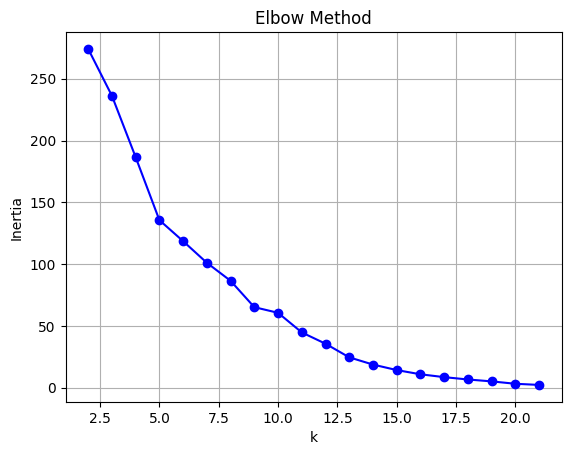

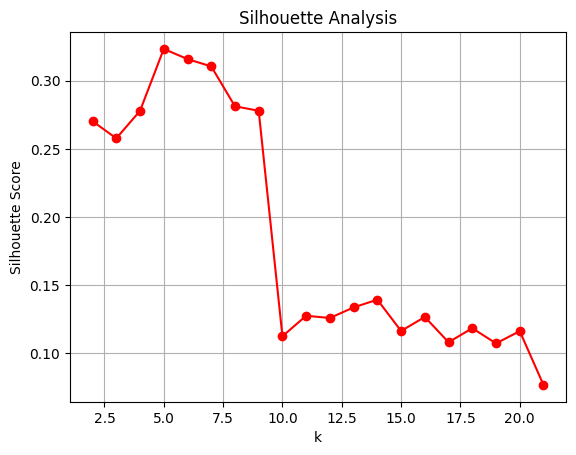

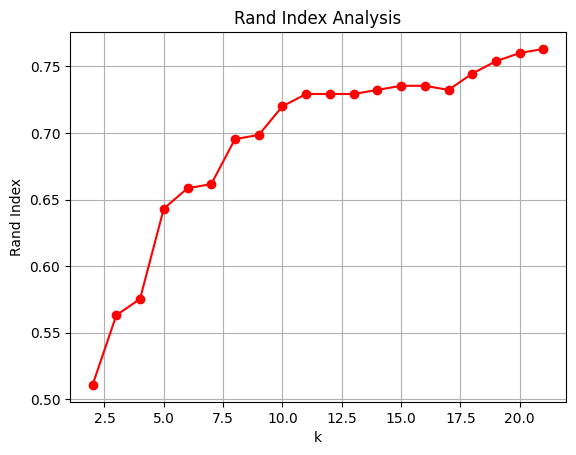

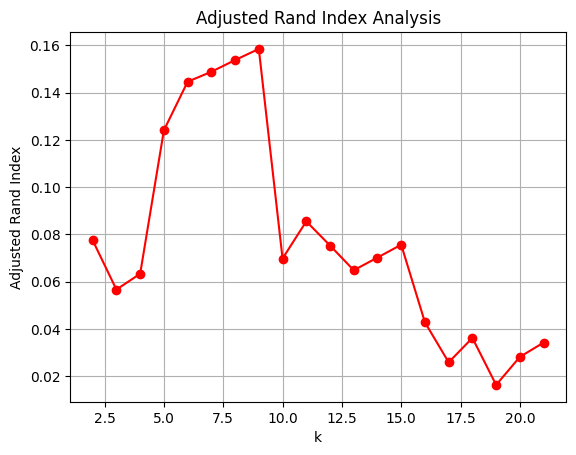

DOMAIN NAMES GROUPED BY CLUSTER

K = 2 CLUSTERS

Cluster 0 (18 domains):
------------------------------
   1. _other other
   2. adnxs.com Ad Tech / Analytics
   3. ads-twitter.com Ad Tech / Analytics
   4. chartbeat.com Ad Tech / Analytics
   5. contextweb.com Ad Tech / Analytics
   6. disqus.com Social & Community
   7. everesttech.net Ad Tech / Analytics
   8. fastly.net Infrastructure & CDN
   9. githubusercontent.com Infrastructure & CDN
  10. krxd.net Ad Tech / Analytics
  11. newrelic.com Ad Tech / Analytics
  12. outbrain.com Ad Tech / Analytics
  13. pinterest.com Social & Community
  14. polyfill.io Infrastructure & CDN
  15. reddit.com Social & Community
  16. taboola.com Ad Tech / Analytics
  17. twitch.tv Media Service
  18. twitchcdn.net Media Service

Cluster 1 (8 domains):
------------------------------
   1. fastly-insights.com Ad Tech / Analytics
   2. ftcdn.net Infrastructure & CDN
   3. giphy.com Media Service
   4. redd.it Social & Community
   5. scdn.co Media Ser

In [43]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, rand_score

X_s, _ = fnc.remove_correlated_features(df_domC, df_domC, correlation_threshold=0.90)

#X_s,_  = remove_correlated_features(df_dom_d, df_dom_d, correlation_threshold=0.7)
#######Tried with PCA and it is just as bad ############
#actualy a lot worse in DBSCAN
#pca = PCA(12)
#X_s = pca.fit_transform(df_domC.dropna())
#plot_corrMat(pd.DataFrame(X_s).corr().abs())
########################################################

# Elbow method

random_state = 21375
inertias = []
sil_scores = []
RI_scores = []
ARI_scores = []
K_range = range(2, 22)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=random_state)
    km.fit(X_s)
    inertias.append(km.inertia_)
    labels_km = km.predict(X_s)
    sil_scores.append(silhouette_score(X_s, labels_km))
    ARI_scores.append(adjusted_rand_score(df_labels['Label_Encoded'], labels_km))
    RI_scores.append(rand_score(df_labels['Label_Encoded'], labels_km))

plt.plot(K_range, inertias, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')   
plt.title('Elbow Method')
plt.grid()

plt.show()

plt.plot(K_range, sil_scores, 'ro-')
plt.grid()
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()



plt.plot(K_range, RI_scores, 'ro-')
plt.grid()
plt.xlabel('k')
plt.ylabel('Rand Index')
plt.title('Rand Index Analysis')
plt.show()

plt.plot(K_range, ARI_scores, 'ro-')
plt.grid()
plt.xlabel('k')
plt.ylabel('Adjusted Rand Index')
plt.title('Adjusted Rand Index Analysis')
plt.show()



print("=" * 60)
print("DOMAIN NAMES GROUPED BY CLUSTER")
print("=" * 60)

for k in range(2, 14):
    km = KMeans(n_clusters=k, random_state=random_state)
    cluster_labels = km.fit_predict(X_s)
    
    # Create a DataFrame with domain names and their cluster assignments
    cluster_df = pd.DataFrame({
        'domain': df_domC.index,
        'cluster': cluster_labels
    })
    
    print(f"\n{'='*40}")
    print(f"K = {k} CLUSTERS")
    print(f"{'='*40}")
    
    # Group domains by cluster and print
    for cluster_id in range(k):
        domains_in_cluster = cluster_df[cluster_df['cluster'] == cluster_id]['domain'].tolist()
        print(f"\nCluster {cluster_id} ({len(domains_in_cluster)} domains):")
        print("-" * 30)
        
        # Print domains in a readable format (wrap text if needed)
        for i, domain in enumerate(domains_in_cluster, 1):
            print(f"  {i:2d}. {domain}", domain_labels[domain])
    
    # Print some statistics
    cluster_sizes = cluster_df['cluster'].value_counts().sort_index()
    print(f"\nCluster size distribution:")
    for cluster_id, size in cluster_sizes.items():
        print(f"  Cluster {cluster_id}: {size} domains")
    
    # Calculate silhouette score for this k
    sil_score = silhouette_score(X_s, cluster_labels)
    print(f"  Silhouette Score: {sil_score:.4f}")


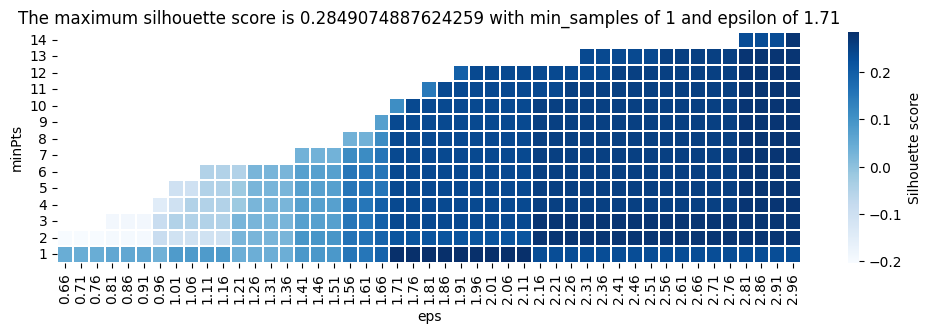

Number of clusters (including noise):  13
Size of each cluster:  [ 1 13  2  1  1  1  1  1  1  1  1  1  1]
Silhouette: 0.28
RI: 0.72
ARI: 0.23


In [77]:
from sklearn.cluster import DBSCAN

# Now analyze the performance varying epsilon and min_samples.

shs = []
for eps in np.arange(0.01, 3.0, 0.05):
    eps = round(eps,5)
    for mins in range(1, 15):
        dbscan = DBSCAN(eps=eps, min_samples=mins)
        cl_labels3 = dbscan.fit_predict(X_s)
        try:
            silhouette  = silhouette_score(X_s, cl_labels3)
        except:
            silhouette = np.nan
        shs.append((eps, mins, silhouette))

gs = pd.DataFrame(shs, columns=['eps', 'minPts', 'sh'])
gs = pd.pivot_table(gs, columns='eps', index='minPts', values='sh', aggfunc=lambda x:x)

# Plot the silhouette score for the different values with a heatmap

plt.figure(figsize=(12,3))
max_ss = gs.max().max()
mins_max_ss = gs.stack().idxmax()[0]
eps_max_ss = gs.stack().idxmax()[1]
plt.title(f'The maximum silhouette score is {max_ss} with min_samples of {mins_max_ss} and epsilon of {eps_max_ss}')
sns.heatmap(gs, cmap='Blues', cbar_kws={'label':'Silhouette score'}, linewidths=.005)
plt.gca().invert_yaxis()
plt.show()

# Report the results of the best combination, also on other metrics

dbscan = DBSCAN(eps=eps_max_ss, min_samples=mins_max_ss )
cl_labels = dbscan.fit_predict(X_s) # Get clusters ID

# Unsupervised metric
silhouette  = silhouette_score(X_s, cl_labels)
# Supervised metrics
ri = rand_score(df_labels['Label_Encoded'], cl_labels)
ari = adjusted_rand_score(df_labels['Label_Encoded'], cl_labels)

# report number and size of each cluster
(unique, counts)=np.unique( cl_labels, return_counts=True)
print("Number of clusters (including noise): ", len(unique))
print("Size of each cluster: ", counts)
# report usupervised and supervised metric
print(f'Silhouette: {round(silhouette, 2)}')
print(f'RI: {round(ri, 2)}')
print(f'ARI: {round(ari, 2)}')

In [30]:


cluster_labels = dbscan.fit_predict(X_s)

# Create a DataFrame with domain names and their cluster assignments
cluster_df = pd.DataFrame({
    'domain': df_domC.index,
    'cluster': cluster_labels
})

print(f"\n{'='*40}")
print(f"K = {k} CLUSTERS")
print(f"{'='*40}")

# Group domains by cluster and print
for cluster_id in range(k):
    domains_in_cluster = cluster_df[cluster_df['cluster'] == cluster_id]['domain'].tolist()
    print(f"\nCluster {cluster_id} ({len(domains_in_cluster)} domains):")
    print("-" * 30)
    
    # Print domains in a readable format (wrap text if needed)
    for i, domain in enumerate(domains_in_cluster, 1):
        print(f"  {i:2d}. {domain}", domain_labels[domain])

# Print some statistics
cluster_sizes = cluster_df['cluster'].value_counts().sort_index()
print(f"\nCluster size distribution:")
for cluster_id, size in cluster_sizes.items():
    print(f"  Cluster {cluster_id}: {size} domains")

# Calculate silhouette score for this k
sil_score = silhouette_score(X_s, cluster_labels)
print(f"  Silhouette Score: {sil_score:.4f}")


K = 13 CLUSTERS

Cluster 0 (1 domains):
------------------------------
   1. _other other

Cluster 1 (13 domains):
------------------------------
   1. adnxs.com Ad Tech / Analytics
   2. ads-twitter.com Ad Tech / Analytics
   3. chartbeat.com Ad Tech / Analytics
   4. contextweb.com Ad Tech / Analytics
   5. disqus.com Social & Community
   6. everesttech.net Ad Tech / Analytics
   7. fastly.net Infrastructure & CDN
   8. githubusercontent.com Infrastructure & CDN
   9. krxd.net Ad Tech / Analytics
  10. newrelic.com Ad Tech / Analytics
  11. outbrain.com Ad Tech / Analytics
  12. pinterest.com Social & Community
  13. polyfill.io Infrastructure & CDN

Cluster 2 (2 domains):
------------------------------
   1. fastly-insights.com Ad Tech / Analytics
   2. ftcdn.net Infrastructure & CDN

Cluster 3 (1 domains):
------------------------------
   1. giphy.com Media Service

Cluster 4 (1 domains):
------------------------------
   1. redd.it Social & Community

Cluster 5 (1 domains):
---

In [82]:
from collections import defaultdict

# Build cluster → domains mapping
clusters = defaultdict(list)

for domain, category, cluster in zip(
    df_labels.index,
    df_labels["Primary_Label"],
    cl_labels
):
    clusters[cluster].append((domain, category))

# Sort clusters (noise last)
sorted_clusters = sorted(
    clusters.items(),
    key=lambda x: (x[0] == -1, x[0])
)

# Count non-noise clusters
k_clusters = len([c for c in clusters.keys() if c != -1])

print("=" * 40)
print(f"K = {k_clusters} CLUSTERS")
print("=" * 40)
print()

# Print clusters
for cluster_id, items in sorted_clusters:
    cluster_name = "Noise" if cluster_id == -1 else f"Cluster {cluster_id}"
    
    print(f"{cluster_name} ({len(items)} domains):")
    print("-" * 30)
    
    for i, (domain, category) in enumerate(sorted(items), 1):
        print(f"{i:>4}. {domain} {category}")
    
    print()


K = 13 CLUSTERS

Cluster 0 (1 domains):
------------------------------
   1. _other other

Cluster 1 (13 domains):
------------------------------
   1. adnxs.com Ad Tech / Analytics
   2. ads-twitter.com Ad Tech / Analytics
   3. chartbeat.com Ad Tech / Analytics
   4. contextweb.com Ad Tech / Analytics
   5. disqus.com Social & Community
   6. everesttech.net Ad Tech / Analytics
   7. fastly.net Infrastructure & CDN
   8. githubusercontent.com Infrastructure & CDN
   9. krxd.net Ad Tech / Analytics
  10. newrelic.com Ad Tech / Analytics
  11. outbrain.com Ad Tech / Analytics
  12. pinterest.com Social & Community
  13. polyfill.io Infrastructure & CDN

Cluster 2 (2 domains):
------------------------------
   1. fastly-insights.com Ad Tech / Analytics
   2. ftcdn.net Infrastructure & CDN

Cluster 3 (1 domains):
------------------------------
   1. giphy.com Media Service

Cluster 4 (1 domains):
------------------------------
   1. redd.it Social & Community

Cluster 5 (1 domains):
----

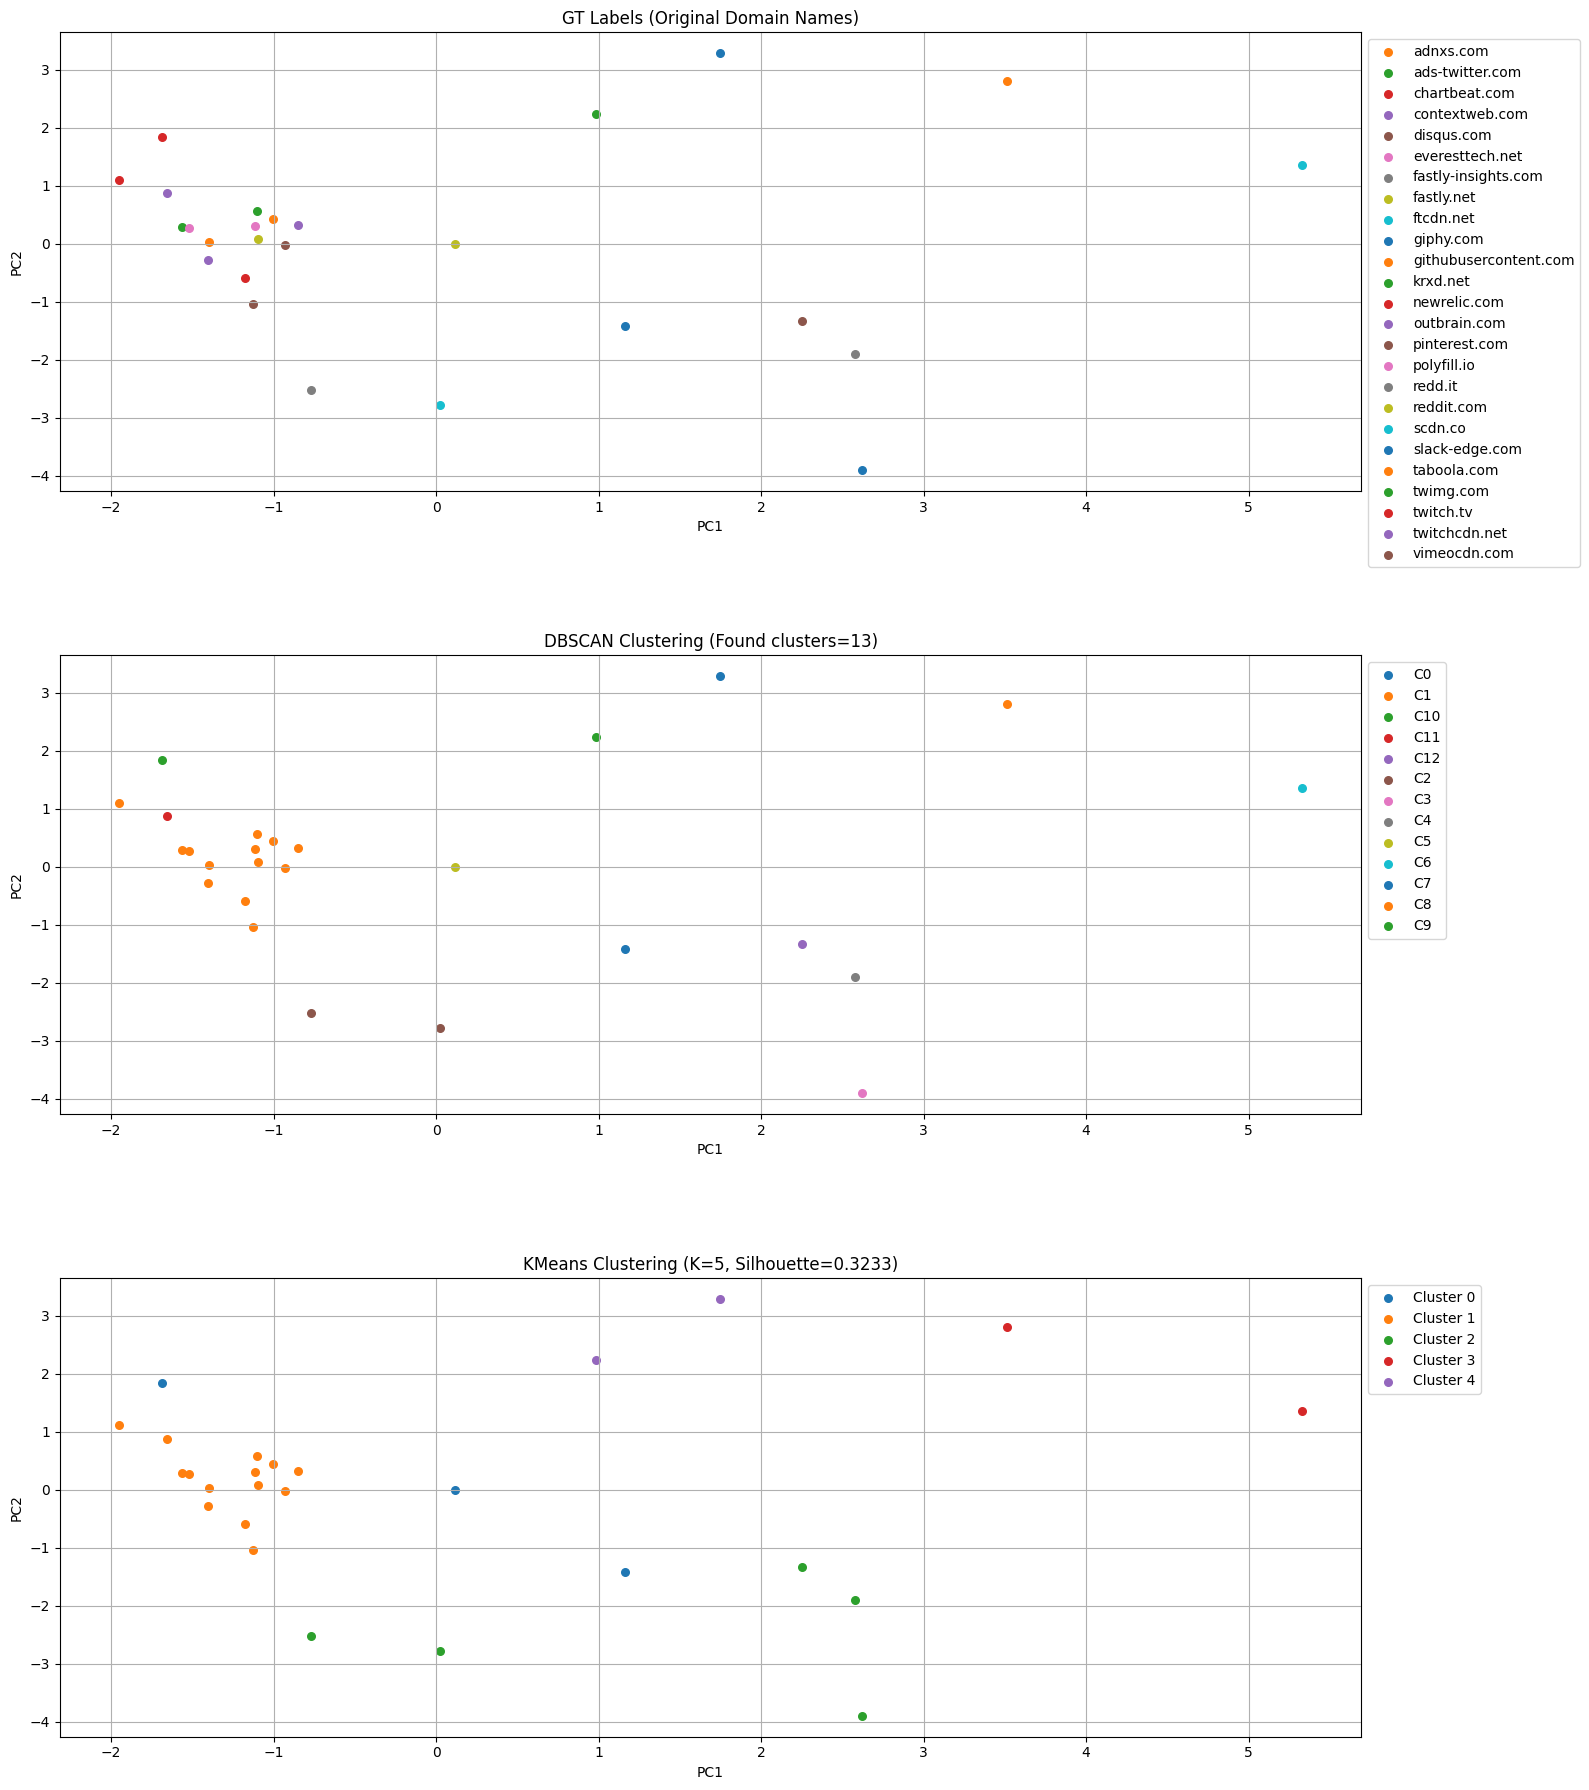

KMeans Clustering Results (K=5, Best Silhouette Score)

KMeans: K = 5 CLUSTERS

Cluster 0 (3 domains):
------------------------------
   1. reddit.com
   2. slack-edge.com
   3. twitch.tv

Cluster 1 (14 domains):
------------------------------
   1. adnxs.com
   2. ads-twitter.com
   3. chartbeat.com
   4. contextweb.com
   5. disqus.com
   6. everesttech.net
   7. fastly.net
   8. githubusercontent.com
   9. krxd.net
  10. newrelic.com
  11. outbrain.com
  12. pinterest.com
  13. polyfill.io
  14. twitchcdn.net

Cluster 2 (5 domains):
------------------------------
   1. fastly-insights.com
   2. ftcdn.net
   3. giphy.com
   4. redd.it
   5. vimeocdn.com

Cluster 3 (2 domains):
------------------------------
   1. scdn.co
   2. taboola.com

Cluster 4 (2 domains):
------------------------------
   1. _other
   2. twimg.com

Cluster size distribution:
  Cluster 0: 3 domains
  Cluster 1: 14 domains
  Cluster 2: 5 domains
  Cluster 3: 2 domains
  Cluster 4: 2 domains

Silhouette Score: 0.

In [85]:
# First, find the K with the best silhouette score from your KMeans analysis
best_k_idx = np.argmax(sil_scores)  # Find index of maximum silhouette score
best_k = K_range[best_k_idx]  # Get the corresponding K value
best_sil_score = sil_scores[best_k_idx]  # Get the best silhouette score

# Fit KMeans with the best K
km_best = KMeans(n_clusters=best_k, random_state=random_state)
km_labels = km_best.fit_predict(X_s)

# Fit PCA for 2D projection (reuse from your DBSCAN code)
pca = PCA(n_components=2)
projection = pd.DataFrame(pca.fit_transform(X_s))

# Get DBSCAN labels from your previous code (assuming cl_labels exists)
projection['dbscan_cluster'] = [f'C{x}' for x in cl_labels]  # cluster IDs from DBSCAN
projection['kmeans_cluster'] = km_labels  # KMeans cluster labels
projection['label'] = df_domC.index  # Original domain labels

fig, axs = plt.subplots(3, 1, figsize=(16, 18))

# Plot 1: Original domain labels (GT Labels)
for i in np.unique(projection.label):
    subdf = projection[projection.label == i]
    axs[0].scatter(subdf[0], subdf[1], label=i, s=30)
axs[0].grid()
axs[0].legend(bbox_to_anchor=(1, 1), loc="upper left")
axs[0].set_xlabel('PC1')
axs[0].set_ylabel('PC2')
axs[0].set_title('GT Labels (Original Domain Names)')

# Plot 2: DBSCAN clustering
for i in np.unique(projection.dbscan_cluster):
    subdf = projection[projection.dbscan_cluster == i]
    axs[1].scatter(subdf[0], subdf[1], label=i, s=30)
axs[1].grid()
axs[1].legend(bbox_to_anchor=(1, 1), loc="upper left")
axs[1].set_xlabel('PC1')
axs[1].set_ylabel('PC2')
axs[1].set_title(f'DBSCAN Clustering (Found clusters={len(np.unique(cl_labels))})')

# Plot 3: KMeans clustering with best silhouette score
for i in np.unique(projection.kmeans_cluster):
    subdf = projection[projection.kmeans_cluster == i]
    axs[2].scatter(subdf[0], subdf[1], label=f'Cluster {i}', s=30)
axs[2].grid()
axs[2].legend(bbox_to_anchor=(1, 1), loc="upper left")
axs[2].set_xlabel('PC1')
axs[2].set_ylabel('PC2')
axs[2].set_title(f'KMeans Clustering (K={best_k}, Silhouette={best_sil_score:.4f})')

plt.tight_layout()
plt.show()

# Print KMeans clustering details
print("=" * 60)
print(f"KMeans Clustering Results (K={best_k}, Best Silhouette Score)")
print("=" * 60)

# Create a DataFrame with domain names and their KMeans cluster assignments
kmeans_cluster_df = pd.DataFrame({
    'domain': df_domC.index,
    'cluster': km_labels
})

print(f"\n{'='*40}")
print(f"KMeans: K = {best_k} CLUSTERS")
print(f"{'='*40}")

# Group domains by cluster and print
for cluster_id in range(best_k):
    domains_in_cluster = kmeans_cluster_df[kmeans_cluster_df['cluster'] == cluster_id]['domain'].tolist()
    print(f"\nCluster {cluster_id} ({len(domains_in_cluster)} domains):")
    print("-" * 30)
    
    # Print domains in a readable format
    for i, domain in enumerate(domains_in_cluster, 1):
        print(f"  {i:2d}. {domain}")

# Print some statistics
kmeans_cluster_sizes = kmeans_cluster_df['cluster'].value_counts().sort_index()
print(f"\nCluster size distribution:")
for cluster_id, size in kmeans_cluster_sizes.items():
    print(f"  Cluster {cluster_id}: {size} domains")

# Calculate silhouette score for KMeans
kmeans_sil_score = silhouette_score(X_s, km_labels)
print(f"\nSilhouette Score: {kmeans_sil_score:.4f}")

# Compare with DBSCAN
dbscan_sil_score = silhouette_score(X_s, cl_labels)
print(f"DBSCAN Silhouette Score: {dbscan_sil_score:.4f}")

/tmp/ipykernel_110115/3560014194.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_labels))


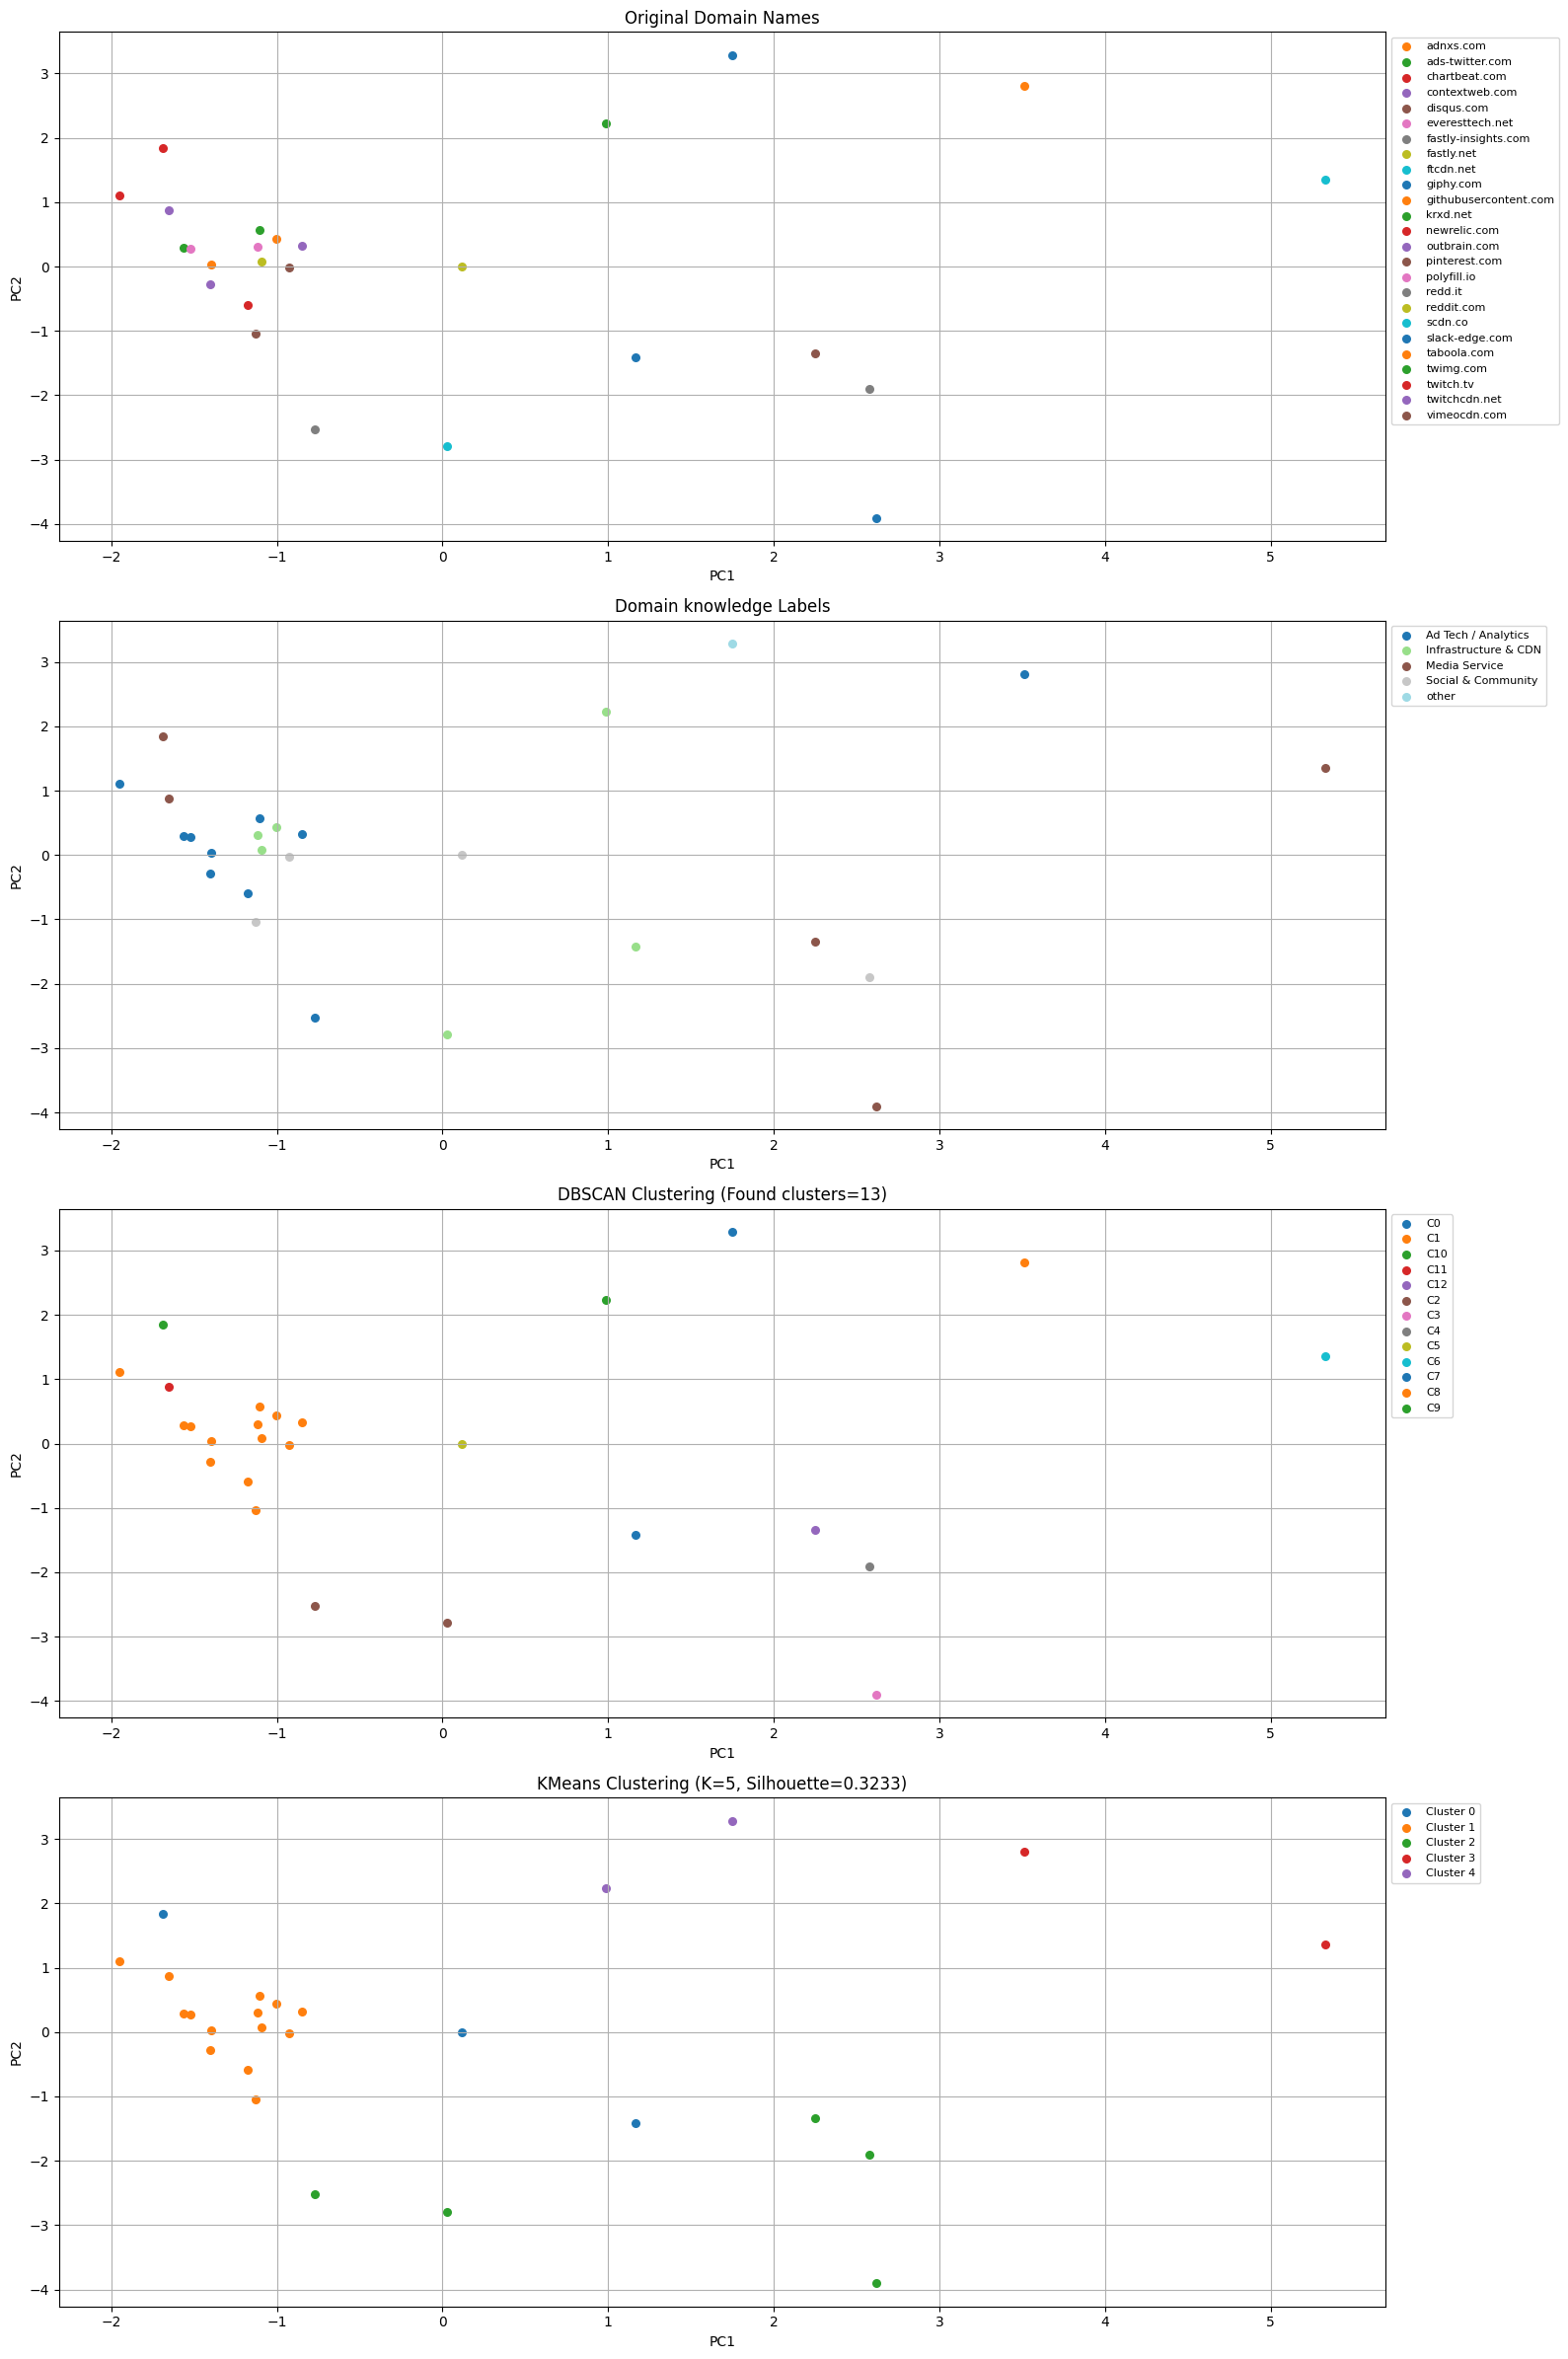

In [89]:
# First, find the K with the best silhouette score from your KMeans analysis
best_k_idx = np.argmax(sil_scores)  # Find index of maximum silhouette score
best_k = K_range[best_k_idx]  # Get the corresponding K value
best_sil_score = sil_scores[best_k_idx]  # Get the best silhouette score

# Fit KMeans with the best K
km_best = KMeans(n_clusters=best_k, random_state=random_state)
km_labels = km_best.fit_predict(X_s)

# Fit PCA for 2D projection
pca = PCA(n_components=2)
projection = pd.DataFrame(pca.fit_transform(X_s))

# Add all labels to the projection dataframe
projection['dbscan_cluster'] = [f'C{x}' for x in cl_labels]  # cluster IDs from DBSCAN
projection['kmeans_cluster'] = km_labels  # KMeans cluster labels
projection['domain'] = df_domC.index  # Original domain names
projection['primary_label'] = df_labels['Primary_Label'].values  # Primary cluster labels

# Create figure with 4 subplots
fig, axs = plt.subplots(4, 1, figsize=(16, 24))

# Plot 1: Original domain names
for i in np.unique(projection.domain):
    subdf = projection[projection.domain == i]
    axs[0].scatter(subdf[0], subdf[1], label=i, s=30)
axs[0].grid()
axs[0].legend(bbox_to_anchor=(1, 1), loc="upper left", fontsize=8)
axs[0].set_xlabel('PC1')
axs[0].set_ylabel('PC2')
axs[0].set_title('Original Domain Names')

# Plot 2: Primary cluster labels from df_labels
unique_labels = np.unique(projection.primary_label)
# Create a color map for better visualization
cmap = plt.cm.get_cmap('tab20', len(unique_labels))

for idx, label in enumerate(unique_labels):
    subdf = projection[projection.primary_label == label]
    axs[1].scatter(subdf[0], subdf[1], label=label, color=cmap(idx), s=30)
axs[1].grid()
axs[1].legend(bbox_to_anchor=(1, 1), loc="upper left", fontsize=8)
axs[1].set_xlabel('PC1')
axs[1].set_ylabel('PC2')
axs[1].set_title('Domain knowledge Labels')

# Plot 3: DBSCAN clustering
for i in np.unique(projection.dbscan_cluster):
    subdf = projection[projection.dbscan_cluster == i]
    axs[2].scatter(subdf[0], subdf[1], label=i, s=30)
axs[2].grid()
axs[2].legend(bbox_to_anchor=(1, 1), loc="upper left", fontsize=8)
axs[2].set_xlabel('PC1')
axs[2].set_ylabel('PC2')
axs[2].set_title(f'DBSCAN Clustering (Found clusters={len(np.unique(cl_labels))})')

# Plot 4: KMeans clustering with best silhouette score
for i in np.unique(projection.kmeans_cluster):
    subdf = projection[projection.kmeans_cluster == i]
    axs[3].scatter(subdf[0], subdf[1], label=f'Cluster {i}', s=30)
axs[3].grid()
axs[3].legend(bbox_to_anchor=(1, 1), loc="upper left", fontsize=8)
axs[3].set_xlabel('PC1')
axs[3].set_ylabel('PC2')
axs[3].set_title(f'KMeans Clustering (K={best_k}, Silhouette={best_sil_score:.4f})')

plt.tight_layout()
plt.show()